In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (mean_absolute_error,mean_squared_error)

In [2]:
model_df=pd.read_csv(r"C:\Users\ganesh\Desktop\All Projects\Predicative care load Forecasting\data\processed\hhs_feature.csv")

In [3]:
model_df["Date"]= pd.to_datetime(model_df["Date"])

In [4]:
model_df= model_df.sort_values("Date").reset_index(drop=True)

In [5]:
target="Children in HHS Care"

y=model_df[["Date",target]].copy()

In [6]:
y.head()

,Date,Children in HHS Care
0,2023-01-12,6566
1,2023-01-22,7122
2,2023-01-23,7280
3,2023-01-24,7433
4,2023-01-25,7538


In [7]:
y.tail()

,Date,Children in HHS Care
715,2025-12-15,2470
716,2025-12-16,2468
717,2025-12-17,2481
718,2025-12-18,2472
719,2025-12-21,2484


In [8]:
split_index=int(len(y) * 0.80)

train=y.iloc[:split_index].copy()
test=y.iloc[split_index:].copy()

print("Training observation:",len(train))
print("Testing observation:",len(test))

Training observation: 576
Testing observation: 144


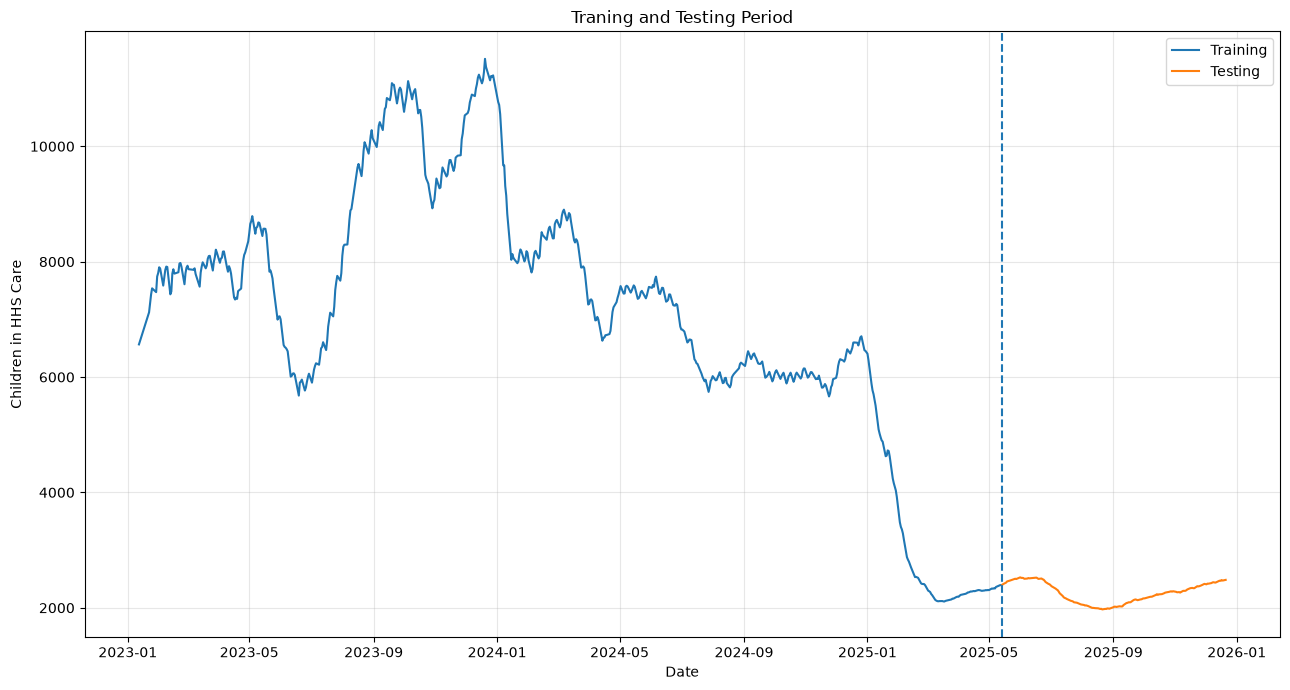

In [9]:
plt.figure(figsize=(13,7))

plt.plot(
    train["Date"],
    train[target],
    label="Training"
)

plt.plot(
    test["Date"],
    test[target],
    label="Testing"
)

plt.axvline(
    test["Date"].iloc[0],
    linestyle="--"
)

plt.title("Traning and Testing Period")
plt.xlabel("Date")
plt.ylabel("Children in HHS Care")
plt.legend()
plt.tight_layout()
plt.grid(alpha=0.3)
plt.show()



# 1.BASELINE MODELS

# 1) NAIVE FORECAST

In [10]:
naive_predication=np.repeat(
    train[target].iloc[-1],
    len(test)
)

In [11]:
naive_mae=mean_absolute_error(
    test[target],
    naive_predication
)

print("Naive MAE:",naive_mae)

Naive MAE: 186.50694444444446


In [12]:
naive_rmse=np.sqrt(
    mean_squared_error(
        test[target],
        naive_predication
    )
)

print("Naive RMSE:",naive_rmse)

Naive RMSE: 227.22854684216065


# 2) MOVING AVERAGE 

In [13]:
window=7
moving_average_predication=np.repeat(
    train[target].tail(window).mean(),
    len(test)
)

In [14]:
ma_mae=mean_absolute_error(
    test[target],
    moving_average_predication
)

ma_rmse=np.sqrt(
    mean_squared_error(
        test[target],
        moving_average_predication
    )
)

print("Moving Average MAE:",ma_mae)
print("Moving Average RMSE:",ma_rmse)

Moving Average MAE: 174.73313492063497
Moving Average RMSE: 208.66256400685262


In [15]:
baseline_results=pd.DataFrame({
    "Model":[
        "Naive","7-Day Moving Average"
    ],
    "MAE":[
        naive_mae,ma_mae
    ],
    "RMSE":[
        naive_rmse,ma_rmse
    ]
})

baseline_results

,Model,MAE,RMSE
0,Naive,186.506944,227.228547
1,7-Day Moving Average,174.733135,208.662564


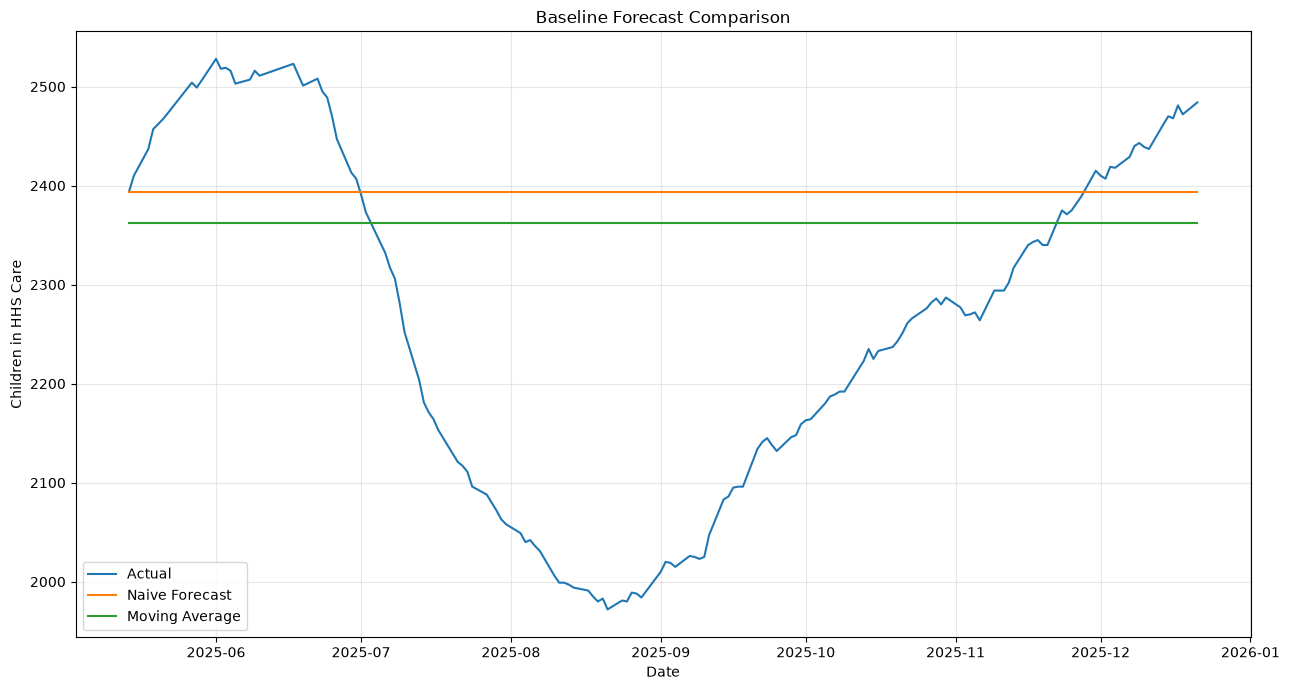

In [16]:
plt.figure(figsize=(13,7))

plt.plot(
    test["Date"],
    test[target],
    label="Actual"
)

plt.plot(
    test["Date"],
    naive_predication,
    label="Naive Forecast"
)

plt.plot(
    test["Date"],
    moving_average_predication,
    label="Moving Average"
)

plt.title("Baseline Forecast Comparison")
plt.xlabel("Date")
plt.ylabel("Children in HHS Care")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 2. EXPONENTIAL SMOOTHING

In [17]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

In [18]:
train_values=train[target].values

exp_model=ExponentialSmoothing(
    train_values,
    trend="add",
    seasonal=None
)

exp_fit=exp_model.fit(
    optimized=True
)

In [19]:
exp_predication=exp_fit.forecast(
    len(test)
)

In [20]:
exp_mae=mean_absolute_error(
    test[target],
    exp_predication
)

exp_rmse=np.sqrt(
    mean_squared_error(
        test[target],
        exp_predication
    )
)

print("Exponential Smoothng MAE:",exp_mae)
print("Exponential Smoothing RMSE:",exp_rmse)

Exponential Smoothng MAE: 703.5138031953934
Exponential Smoothing RMSE: 786.7896260372617


In [21]:
results=pd.DataFrame({
    "model":[
        "Naive",
        "7-Day Moving Average",
        "Exponential Smoothing"
    ],
    "MAE":[
        naive_mae,ma_mae,exp_mae
    ],
    "RMSE":[
        naive_rmse,ma_rmse,exp_rmse
    ]
})

results

,model,MAE,RMSE
0,Naive,186.506944,227.228547
1,7-Day Moving Average,174.733135,208.662564
2,Exponential Smoothing,703.513803,786.789626


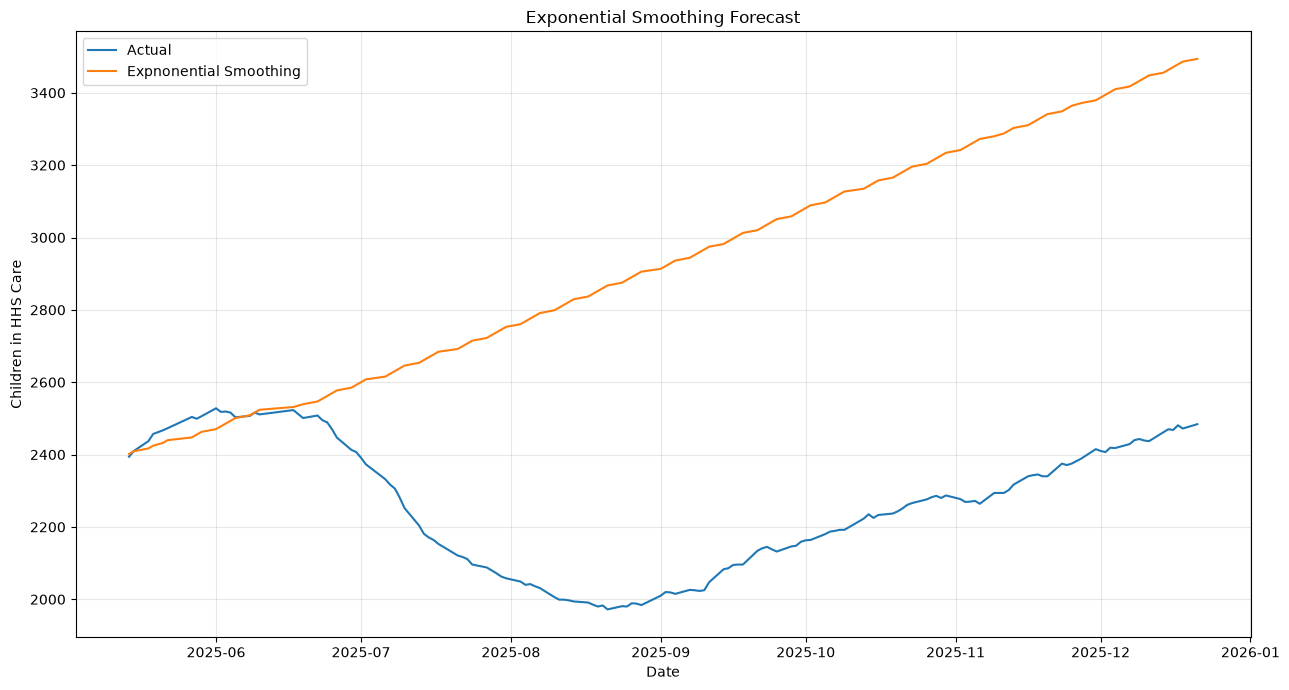

In [22]:
plt.figure(figsize=(13,7))

plt.plot(
    test["Date"],
    test[target],
    label="Actual"
)

plt.plot(
    test["Date"],
    exp_predication,
    label="Expnonential Smoothing"
)

plt.title("Exponential Smoothing Forecast")
plt.xlabel("Date")
plt.ylabel("Children in HHS Care")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Exponential Smoothing Result

Exponential Smoothing produced an MAE of approximately 703.51 and an RMSE of approximately 786.79, substantially worse than both the Naïve and 7-day Moving Average baselines.

The poor performance may be related to the irregular reporting frequency of the source dataset. The data contains systematic missing calendar dates, particularly Fridays and Saturdays. Therefore, standard regular-frequency exponential smoothing is not considered an appropriate final forecasting model for this dataset.

The model is retained as a benchmark but excluded from final model selection.

# 3. ARIMA

In [23]:
from statsmodels.tsa.arima.model import ARIMA

In [24]:
arima_model=ARIMA(
    train[target],
    order=(1,1,1)
)

arima_fit=arima_model.fit()

In [25]:
arima_predication=arima_fit.forecast(
    steps=len(test)
)

In [26]:
arima_mae=mean_absolute_error(
    test[target],
    arima_predication
)

arima_rmse=np.sqrt(
    mean_squared_error(
        test[target],
        arima_predication
    )
)

print("ARIMA MAE:",arima_mae)
print("ARIMA RMSE:",arima_rmse)

ARIMA MAE: 186.63942655311791
ARIMA RMSE: 227.42381125793565


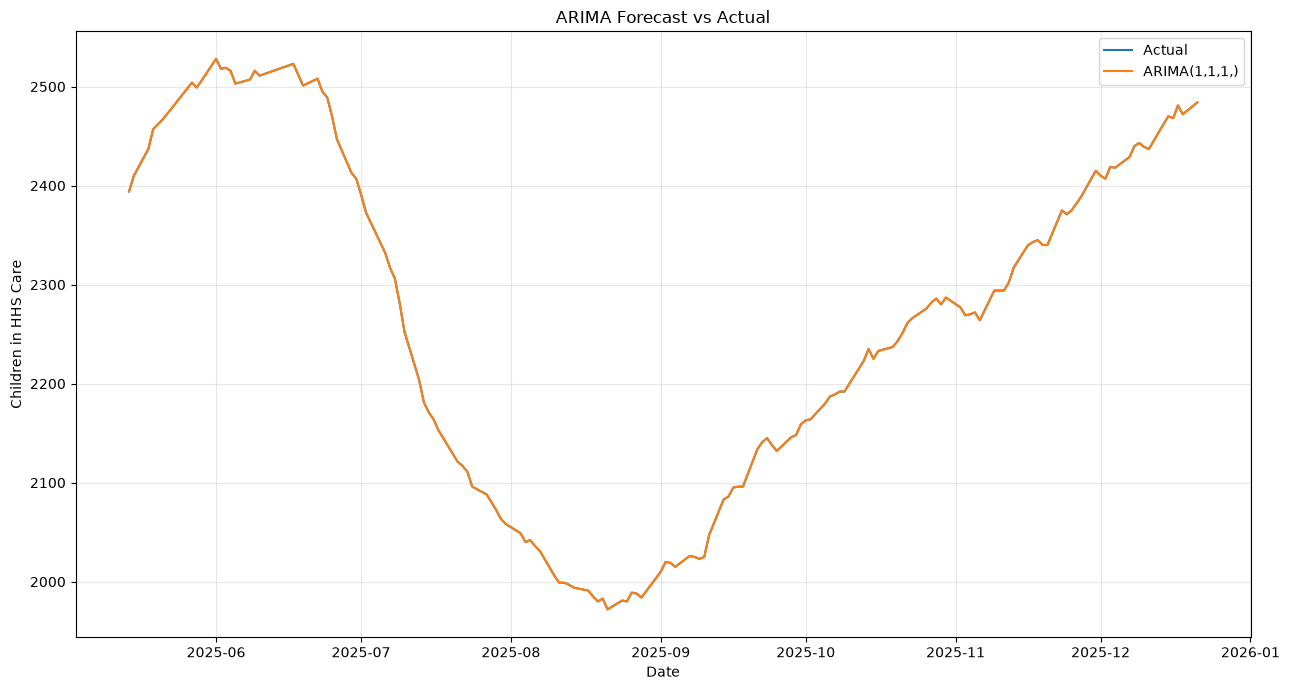

In [27]:
plt.figure(figsize=(13,7))

plt.plot(
    test["Date"],
    test[target],
    label="Actual"
)

plt.plot(
    test["Date"],
    test[target],
    label="ARIMA(1,1,1,)"
)

plt.title("ARIMA Forecast vs Actual")
plt.xlabel("Date")
plt.ylabel("Children in HHS Care")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [28]:
results=pd.DataFrame({
    "Model":[
        "Naive",
        "7-Day Moving Average",
        "Exponential Smoothing",
        "ARIMA(1,1,1)"
    ],
    "MAE":[
        naive_mae,
        ma_mae,
        exp_mae,
        arima_mae
    ],
    "RMSE":[
        naive_rmse,
        ma_rmse,
        exp_rmse,
        arima_rmse
    ]
})

results.sort_values("MAE")

,Model,MAE,RMSE
1,7-Day Moving Average,174.733135,208.662564
0,Naive,186.506944,227.228547
3,"ARIMA(1,1,1)",186.639427,227.423811
2,Exponential Smoothing,703.513803,786.789626


# 4. MACHINE LEARNING MODELS
## 4.1 RANDOM FOREST REGRESSOR

In [29]:
from sklearn.ensemble import RandomForestRegressor

In [30]:
features= [
    "day_of_week",
    "day_of_month",
    "month",
    "quarter",
    "year",
    "week_of_year",
    "is_weekend",
    "Net_Pressure",
    "Discharge_to_Transfer_Ratio",
    "hhs_lag_1",
    "hhs_lag_7",
    "hhs_lag_14",
    "hhs_lag_28",
    "transfer_lag_1",
    "transfer_lag_7",
    "transfer_lag_14",
    "discharge_lag_1",
    "discharge_lag_7",
    "discharge_lag_14",
    "hhs_rolling_mean_7d",
    "hhs_rolling_mean_14d",
    "hhs_rolling_std_7d",
    "hhs_rolling_std_14d"
]

In [31]:
ml_df=model_df[
    ["Date",target] + features
].dropna().copy()

In [32]:
print(ml_df.shape)

(490, 25)


In [33]:
print(ml_df.isna().sum().sum())

0


In [34]:
ml_split= int(len(ml_df)* 0.80)

ml_train=ml_df.iloc[:ml_split].copy()
ml_test=ml_df.iloc[ml_split:].copy()

print("ML training onservations:", len(ml_train))
print("ML testing observations:",len(ml_test))

ML training onservations: 392
ML testing observations: 98


In [35]:
x_train=ml_train[features]
y_train=ml_train[target]

x_test=ml_test[features]
y_test=ml_test[target]


In [36]:
rf_model=RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

In [37]:
rf_model.fit(
    x_train,
    y_train
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max

In [38]:
rf_predication=rf_model.predict(x_test)

In [39]:
rf_mae=mean_absolute_error(
    y_test,
    rf_predication
)

print("Random Forest MAE:",rf_mae)

Random Forest MAE: 72.61409812532511


In [40]:
rf_rmse=np.sqrt(
    mean_squared_error(
        y_test,
        rf_predication
    )
)

print("Random Forest RMSE:",rf_rmse)

Random Forest RMSE: 93.4287682350844


In [41]:
results=pd.DataFrame({
    "Model":[
        "Naive",
        "7-Day Moving Average",
        "Exponential Smoothing",
        "ARIMA(1,1,1)",
        "Random Forest"
    ],
    "MAE":[
        naive_mae,
        ma_mae,
        exp_mae,
        arima_mae,
        rf_mae
    ],
    "RMSE":[
        naive_rmse,
        ma_rmse,
        exp_rmse,
        arima_rmse,
        rf_rmse
    ]
})

results=results.sort_values("MAE")
results

,Model,MAE,RMSE
4,Random Forest,72.614098,93.428768
1,7-Day Moving Average,174.733135,208.662564
0,Naive,186.506944,227.228547
3,"ARIMA(1,1,1)",186.639427,227.423811
2,Exponential Smoothing,703.513803,786.789626


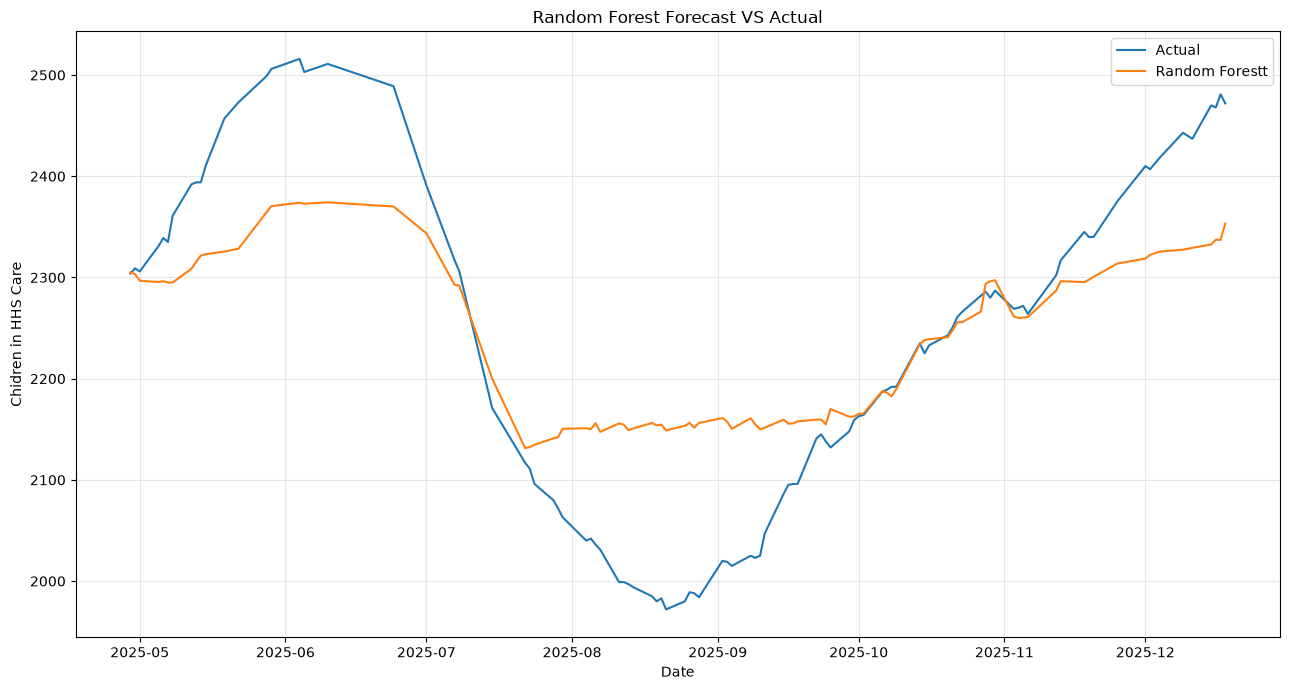

In [42]:
plt.figure(figsize=(13,7))

plt.plot(
    ml_test["Date"],
    y_test,
    label="Actual"
)

plt.plot(
    ml_test["Date"],
    rf_predication,
    label="Random Forestt"
)

plt.title("Random Forest Forecast VS Actual")
plt.xlabel("Date")
plt.ylabel("Chidren in HHS Care")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [43]:
importance=pd.DataFrame({
    "Feature":features,
    "Importance":rf_model.feature_importances_
})

importance=importance.sort_values(
    "Importance",
    ascending=False
)

print(importance)

                        Feature  Importance
9                     hhs_lag_1    0.643000
19          hhs_rolling_mean_7d    0.152738
20         hhs_rolling_mean_14d    0.099044
10                    hhs_lag_7    0.060444
11                   hhs_lag_14    0.030824
4                          year    0.004161
13               transfer_lag_1    0.002363
14               transfer_lag_7    0.001672
12                   hhs_lag_28    0.001586
5                  week_of_year    0.001123
16              discharge_lag_1    0.000878
2                         month    0.000657
15              transfer_lag_14    0.000384
17              discharge_lag_7    0.000291
18             discharge_lag_14    0.000195
7                  Net_Pressure    0.000181
22          hhs_rolling_std_14d    0.000172
1                  day_of_month    0.000085
21           hhs_rolling_std_7d    0.000078
8   Discharge_to_Transfer_Ratio    0.000071
3                       quarter    0.000040
0                   day_of_week 

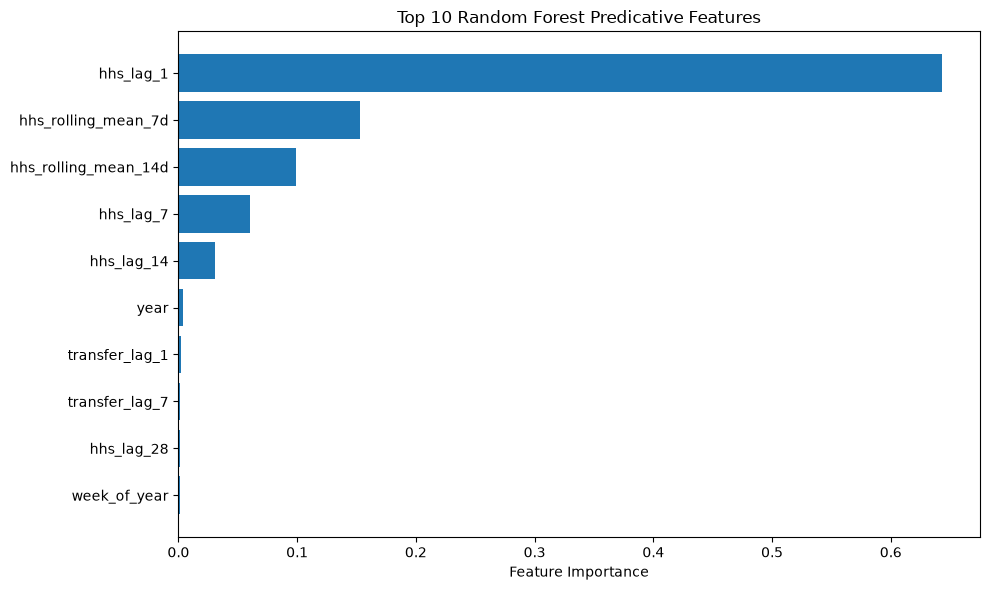

In [44]:
top_features=importance.head(10)

plt.figure(figsize=(10,6))

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.title("Top 10 Random Forest Predicative Features")
plt.xlabel("Feature Importance")
plt.tight_layout()
plt.show()

## 4.2 GRADIENT BOOSTING REGRESSOR

In [45]:
from sklearn.ensemble import GradientBoostingRegressor

In [46]:
gb_model=GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    min_samples_split=5,
    min_samples_leaf=2,
    loss="squared_error",
    random_state=42
)

In [47]:
gb_model.fit(
    x_train,
    y_train
)

,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.05
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",300
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to each Tree estimator at eachboosting iteration.In addition, it controls the random permutation of the features ateach split (see Notes for more details).It also controls the random splitting of the training data to obtain avalidation set if `n_iter_no_change` is not None.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'This parameter has no effect... versionadded:: 0.18.. deprecated:: 1.9 `criterion` is deprecated and will be removed in 1.11.",'deprecated'
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, in

In [48]:
gb_predictions=gb_model.predict(
    x_test
)

In [49]:
gb_mae=mean_absolute_error(
    y_test,
    gb_predictions
)

gb_rmse=np.sqrt(
    mean_squared_error(
        y_test,
        gb_predictions
    )
)

print("Gradient Boosting MAE:",gb_mae)
print("Gradient Boodting RMSE:",gb_rmse)

Gradient Boosting MAE: 70.82673437887598
Gradient Boodting RMSE: 91.84660523015046


In [50]:
results= pd.DataFrame({
    "Model":[
        "Naive",
        "7-Day Moving Average",
        "Exponential Smoothong",
        "ARIMA(1,1,1)",
        "Random Forest",
        "Gradient Boosting"
    ],
    "MAE":[
        naive_mae,
        ma_mae,
        exp_mae,
        arima_mae,
        rf_mae,
        gb_mae
    ],
    "RMSE":[
        naive_rmse,
        ma_rmse,
        exp_rmse,
        arima_rmse,
        rf_rmse,
        gb_rmse
    ]
})

results=results.sort_values("MAE")
results

,Model,MAE,RMSE
5,Gradient Boosting,70.826734,91.846605
4,Random Forest,72.614098,93.428768
1,7-Day Moving Average,174.733135,208.662564
0,Naive,186.506944,227.228547
3,"ARIMA(1,1,1)",186.639427,227.423811
2,Exponential Smoothong,703.513803,786.789626


In [51]:
def calculate_mape(actual, predicted):
    actual=np.array(actual)
    predicted=np.array(predicted)
    
    mask=actual != 0
    
    return(
        np.mean(
            np.abs(
                (actual[mask] - predicted[mask])
                / actual[mask]
            )
        ) * 100
    )

In [52]:
rf_mape= calculate_mape(
    y_test,
    rf_predication
)

gb_mape=calculate_mape(
    y_test,
    gb_predictions
)


print("Random Forest MAPE:",rf_mape)
print("Gradient Boosting MAPE:",gb_mape)

Random Forest MAPE: 3.333074058790971
Gradient Boosting MAPE: 3.2126456387942746


## 5.FORECAST-SAFE FEATURE ENGINEEIRNG

In [53]:
forecast_features= [
    "day_of_week",
    "day_of_month",
    "month",
    "quarter",
    "year",
    "week_of_year",
    "is_weekend",
    "hhs_lag_1",
    "hhs_lag_7",
    "hhs_lag_14",
    "hhs_lag_28",
    "transfer_lag_1",
    "transfer_lag_7",
    "transfer_lag_14",
    "discharge_lag_1",
    "discharge_lag_7",
    "discharge_lag_14",
    "hhs_rolling_mean_7d",
    "hhs_rolling_mean_14d",
    "hhs_rolling_std_7d",
    "hhs_rolling_std_14d"
]

In [54]:
forecast_df= model_df[
    ["Date",target] + forecast_features
].dropna().copy()

In [55]:
print(forecast_df.shape)

(491, 23)


In [56]:
print(forecast_df.isna().sum().sum())

0


In [57]:
forecast_spilt=int(len(forecast_df) * 0.80)

forecast_train=forecast_df.iloc[:forecast_spilt].copy()
forecast_test=forecast_df.iloc[forecast_spilt:].copy()

print("Training:",len(forecast_train))
print("Testing:",len(forecast_test))

Training: 392
Testing: 99


In [58]:
x_train_fs= forecast_train[forecast_features]
y_train_fs= forecast_train[target]

x_test_fs= forecast_test[forecast_features]
y_test_fs= forecast_test[target]

In [59]:
rf_fs= RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_fs.fit(
    x_train_fs,
    y_train_fs
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max

In [60]:
rf_fs_predictions= rf_fs.predict(
    x_test_fs
)

In [61]:
rf_fs_mae= mean_absolute_error(
    y_test_fs,
    rf_fs_predictions
)

rf_fs_rmse= np.sqrt(
    mean_squared_error(
        y_test_fs,
        rf_fs_predictions
    )
)

rf_fs_mape= calculate_mape(
    y_test_fs,
    rf_fs_predictions
)

print("Forecast-Safe Random forest")
print("MAE:",rf_fs_mae)
print("RMSE:",rf_fs_rmse)
print("MAPE:",rf_fs_mape)

Forecast-Safe Random forest
MAE: 72.47109876057314
RMSE: 93.49535531472388
MAPE: 3.3168789878868052


In [62]:
gb_fs= GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    min_samples_split=5,
    min_samples_leaf=2,
    loss="squared_error",
    random_state=42
)

gb_fs.fit(
    x_train_fs,
    y_train_fs
)

,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.05
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",300
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to each Tree estimator at eachboosting iteration.In addition, it controls the random permutation of the features ateach split (see Notes for more details).It also controls the random splitting of the training data to obtain avalidation set if `n_iter_no_change` is not None.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'This parameter has no effect... versionadded:: 0.18.. deprecated:: 1.9 `criterion` is deprecated and will be removed in 1.11.",'deprecated'
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, in

In [63]:
gb_fs_predictions= gb_fs.predict(
    x_test_fs
)

In [64]:
gb_fs_mae= mean_absolute_error(
    y_test_fs,
    gb_fs_predictions
)

gb_fs_rmse= np.sqrt(
    mean_squared_error(
    y_test_fs,
    gb_fs_predictions
    )
)

gb_fs_mape= calculate_mape(
    y_test_fs,
    gb_fs_predictions
)

print("Forecast-Safe Gradient Boosting")
print("Mae:",gb_fs_mae)
print("RMSE:",gb_fs_rmse)
print("MAPE:",gb_fs_mape)

Forecast-Safe Gradient Boosting
Mae: 69.01054367061867
RMSE: 88.7575365835688
MAPE: 3.1070219024992336


In [65]:
final_comparison= pd.DataFrame({
    "Model":[
        "Naive",
        "7-Day Moving Average",
        "ARIMA(1,1,1)",
        "Random Forest - All Features",
        "Gradient Boosting - All Features",
        "Random Forest - Forecast Safe",
        "Gradient Boosting - Forecast Safe"
    ],
    
    "MAE":[
        naive_mae,
        ma_mae,
        arima_mae,
        rf_mae,
        gb_mae,
        rf_fs_mae,
        gb_fs_mae
    ],
    
    "RMSE":[
        naive_rmse,
        ma_rmse,
        arima_rmse,
        rf_rmse,
        gb_rmse,
        rf_fs_rmse,
        gb_fs_rmse 
    ],
    
    "MAPE":[
        calculate_mape(test[target], naive_predication),
        calculate_mape(test[target], moving_average_predication),
        calculate_mape(test[target], arima_predication),
        rf_mape,
        gb_mape,
        rf_fs_mape,
        gb_fs_mape
    ]
})

final_comparison= final_comparison.sort_values(
    "MAE"
).reset_index(drop=True)

final_comparison

,Model,MAE,RMSE,MAPE
0,Gradient Boosting - Forecast Safe,69.010544,88.757537,3.107022
1,Gradient Boosting - All Features,70.826734,91.846605,3.212646
2,Random Forest - Forecast Safe,72.471099,93.495355,3.316879
3,Random Forest - All Features,72.614098,93.428768,3.333074
4,7-Day Moving Average,174.733135,208.662564,8.157753
5,Naive,186.506944,227.228547,8.764874
6,"ARIMA(1,1,1)",186.639427,227.423811,8.771536


## 6. WALK-FORWARD VALIDATION

In [66]:
n= len(forecast_df)

test_size=int(n * 10)
initial_train_size= int(n * 0.60)

print("Total observation:", n)
print("Initial training size:", initial_train_size)
print("Validation size per fold:", test_size)

Total observation: 491
Initial training size: 294
Validation size per fold: 4910


In [67]:
walk_forward_results = []

n = len(forecast_df)

initial_train_size = int(n * 0.60)
test_size = int(n * 0.08)

print("Total observations:", n)
print("Initial training size:", initial_train_size)
print("Test size per fold:", test_size)

Total observations: 491
Initial training size: 294
Test size per fold: 39


In [68]:
for fold in range(1,5):
    train_end= initial_train_size + ((fold - 1) * test_size)
    
    test_start= train_end
    test_end= test_start + test_size
    
    print(f"\nFold {fold}")
    
    print("Train:",0,"to",train_end - 1)
    print("Test:",test_start,"to",test_end - 1)
    
    if test_end > n :
        print("Skipping fold - noyt enough observation")
        continue
    
    train_fold= forecast_df.iloc[:train_end].copy()
    test_fold= forecast_df.iloc[test_start:test_end].copy()
    
    x_train_fold= train_fold[forecast_features]
    y_train_fold= train_fold[target]
    
    x_test_fold= test_fold[forecast_features]
    y_test_fold= test_fold[target]
    
    model= GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        min_samples_split=5,
        min_samples_leaf=2,
        loss="squared_error",
        random_state=42
    )
    
    model.fit(
        x_train_fold,
        y_train_fold
    )
    
    predictions= model.predict(
        x_test_fold
    )
    
    mae= mean_absolute_error(
        y_test_fold,
        predictions
    )
    
    rmse= np.sqrt(
        mean_squared_error(
            y_test_fold,
            predictions
        )
    )
    
    mape= calculate_mape(
        y_test_fold,
        predictions
    )
    
    walk_forward_results.append({
        "Fold": fold + 1,
        "Train_Size": len(train_fold),
        "Test_size": len(test_fold),
        "Test_Start": test_fold["Date"].min(),
        "Test_End": test_fold["Date"].max(),
        "MAE": mae,
        "RMSE": rmse,
        "MAPE": mape
    })
    
print("\nValidation complete")
print("Number of folds:",len(walk_forward_results))


Fold 1
Train: 0 to 293
Test: 294 to 332

Fold 2
Train: 0 to 332
Test: 333 to 371

Fold 3
Train: 0 to 371
Test: 372 to 410

Fold 4
Train: 0 to 410
Test: 411 to 449

Validation complete
Number of folds: 4


In [69]:
walk_forward_results = pd.DataFrame(
    walk_forward_results
)

walk_forward_results

,Fold,Train_Size,Test_size,Test_Start,Test_End,MAE,RMSE,MAPE
0,2,294,39,2024-10-17,2025-01-06,52.554806,69.350885,0.862674
1,3,333,39,2025-01-08,2025-03-20,2578.797708,2811.416043,101.356000
2,4,372,39,2025-03-24,2025-06-10,115.327006,132.312318,4.859869
3,5,411,39,2025-06-24,2025-09-22,83.566642,97.486763,4.141939


In [70]:
print("Average MAE:",walk_forward_results["MAE"].mean())
print("Average RMSE:",walk_forward_results["RMSE"].mean())
print("Average MAPE:",walk_forward_results["MAPE"].mean())

Average MAE: 707.5615404524011
Average RMSE: 777.6415023545878
Average MAPE: 27.80512048628563


In [71]:
print("MAE std:",walk_forward_results["MAE"].std())
print("RMSE std:",walk_forward_results["RMSE"].std())
print("MAPE std:",walk_forward_results["MAPE"].std())

MAE std: 1247.7539817230881
RMSE std: 1356.0942329297602
MAPE std: 49.06478058671739


In [72]:
mean_mae=walk_forward_results["MAE"].mean()
std_mae=walk_forward_results["MAE"].std()

forecast_stability_index= (1 - (std_mae / mean_mae))* 100

print("Forecast Stability Index:",forecast_stability_index)

Forecast Stability Index: -76.34564774751584


In [73]:
walk_forward_results.to_csv(r"C:\Users\ganesh\Desktop\All Projects\Predicative care load Forecasting\outputs\walk_forward_Validation.csv",index=False)

In [74]:
model_df=model_df.sort_values("Date").reset_index(drop=True)
print(model_df[["Date","Children in HHS Care"]].head())

        Date  Children in HHS Care
0 2023-01-12                  6566
1 2023-01-22                  7122
2 2023-01-23                  7280
3 2023-01-24                  7433
4 2023-01-25                  7538


In [75]:
model_df["Date"]= pd.to_datetime(model_df["Date"])
model_df= model_df.sort_values("Date").reset_index(drop=True)

target_col= "Children in HHS Care"

def create_horizon_target(df, days):
    future_dates= df["Date"] + pd.Timedelta(days = days)
    
    dates= df["Date"].values
    values= df[target_col].values
    
    result= []
    
    for future_date in future_dates:
        idx= np.searchsorted(dates, future_date)
        
        if idx < len(df):
            result.append(values[idx])
        else:
            result.append(np.nan)
    
    return result

model_df["target_1d"]= create_horizon_target(model_df, 1)
model_df["target_7d"]= create_horizon_target(model_df, 7)
model_df["target_14d"]= create_horizon_target(model_df, 14) 
model_df["target_30d"]= create_horizon_target(model_df, 30)

print(
    model_df[
        [
            "Date",
            target_col,
            "target_1d",
            "target_7d",
            "target_14d",
            "target_30d"
        ]
    ].head(20)
)              

         Date  Children in HHS Care  target_1d  target_7d  target_14d  \
0  2023-01-12                  6566     7122.0     7122.0      7472.0   
1  2023-01-22                  7122     7280.0     7472.0      7586.0   
2  2023-01-23                  7280     7433.0     7743.0      7720.0   
3  2023-01-24                  7433     7538.0     7803.0      7855.0   
4  2023-01-25                  7538     7472.0     7903.0      7915.0   
5  2023-01-29                  7472     7743.0     7586.0      7434.0   
6  2023-01-30                  7743     7803.0     7720.0      7483.0   
7  2023-01-31                  7803     7903.0     7855.0      7794.0   
8  2023-02-01                  7903     7879.0     7915.0      7869.0   
9  2023-02-02                  7879     7586.0     7908.0      7793.0   
10 2023-02-05                  7586     7720.0     7434.0      7817.0   
11 2023-02-06                  7720     7855.0     7483.0      7817.0   
12 2023-02-07                  7855     7915.0     

In [76]:
horizon_counts= pd.DataFrame({
    "1-Day": model_df["target_1d"].notna().sum(),
    "7-Day": model_df["target_7d"].notna().sum(),
    "14-Day": model_df["target_14d"].notna().sum(),
    "30-Day": model_df["target_30d"].notna().sum()
}, index=["Usable Observations"])

horizon_counts

,1-Day,7-Day,14-Day,30-Day
Usable Observations,719,715,710,700


In [77]:
def check_horizon_coverage(df, days):
    future_dates= df["Date"] + pd.Timedelta(days=days)
     
    dates= df["Date"].values
    actual_gaps=[]
    
    for i, future_date in enumerate(future_dates):
        idx= np.searchsorted(dates, future_date)
        
        if idx < len(df):
            actual_gap= (
                df.loc[idx, "Date"] - df.loc[i, "Date"]
            ).days
            
            actual_gaps.append(actual_gap)
    return pd.Series(actual_gaps)

for horizon in [1,7,14,30]:
    gaps= check_horizon_coverage(model_df, horizon)
    
    print(f"\n{horizon}-Day Horizon")
    print("Minimum actual gap:", gaps.min())
    print("Maxmum actual gap:",gaps.max())
    print("Average actual gap:",gaps.mean())
    
       


1-Day Horizon
Minimum actual gap: 1
Maxmum actual gap: 10
Average actual gap: 1.493741307371349

7-Day Horizon
Minimum actual gap: 7
Maxmum actual gap: 13
Average actual gap: 7.0979020979020975

14-Day Horizon
Minimum actual gap: 14
Maxmum actual gap: 20
Average actual gap: 14.1

30-Day Horizon
Minimum actual gap: 30
Maxmum actual gap: 36
Average actual gap: 30.73


In [78]:
date_to_value= model_df.set_index("Date")["Children in HHS Care"]

def create_exact_horizon_target(df, days):
    future_dates= df["Date"] + pd.Timedelta(days=days)
    return future_dates.map(date_to_value)

model_df["exact_target_1d"]= create_exact_horizon_target(model_df, 1)
model_df["exact_target_7d"]= create_exact_horizon_target(model_df, 7)
model_df["exact_target_14d"]= create_exact_horizon_target(model_df, 14)
model_df["exact_target_30d"]= create_exact_horizon_target(model_df, 30)

In [79]:
exact_counts = pd.DataFrame({
    "1-Day": model_df["exact_target_1d"].notna().sum(),
    "7-Day": model_df["exact_target_7d"].notna().sum(),
    "14-Day": model_df["exact_target_14d"].notna().sum(),
    "30-Day": model_df["exact_target_30d"].notna().sum()
}, index=["Exact Calendar Observations"])

exact_counts

,1-Day,7-Day,14-Day,30-Day
Exact Calendar Observations,558,673,666,402


In [80]:
forecast_features = [
    "hhs_lag_1",
    "hhs_lag_7",
    "hhs_lag_14",
    "hhs_lag_28",
    "transfer_lag_1",
    "transfer_lag_7",
    "transfer_lag_14",
    "discharge_lag_1",
    "discharge_lag_7",
    "discharge_lag_14",
    "hhs_rolling_mean_7d",
    "hhs_rolling_mean_14d",
    "hhs_rolling_std_7d",
    "hhs_rolling_std_14d",
    "day_of_week",
    "day_of_month",
    "month",
    "quarter",
    "year",
    "week_of_year",
    "is_weekend"
]

print("Number of features:", len(forecast_features))

print("\nMissing features:")

missing_features = [
    col for col in forecast_features
    if col not in model_df.columns
]

print(missing_features)

Number of features: 21

Missing features:
[]


In [81]:
forecast_df

,Date,Children in HHS Care,day_of_week,day_of_month,month,quarter,year,week_of_year,is_weekend,hhs_lag_1,...,transfer_lag_1,transfer_lag_7,transfer_lag_14,discharge_lag_1,discharge_lag_7,discharge_lag_14,hhs_rolling_mean_7d,hhs_rolling_mean_14d,hhs_rolling_std_7d,hhs_rolling_std_14d
21,2023-02-21,7967,1,21,2,1,2023,8,0,7817.0,...,184.0,220.0,20.0,209.0,223.0,200.0,7861.50,7775.555556,77.155687,189.400443
22,2023-02-22,7978,2,22,2,1,2023,8,0,7967.0,...,217.0,172.0,169.0,213.0,290.0,317.0,7888.75,7782.555556,97.304933,196.239083
25,2023-02-27,7800,0,27,2,1,2023,9,0,7609.0,...,176.0,184.0,172.0,323.0,209.0,244.0,7853.60,7837.888889,153.854802,112.508271
26,2023-02-28,7896,1,28,2,1,2023,9,0,7800.0,...,166.0,217.0,220.0,248.0,213.0,223.0,7839.40,7849.222222,143.714300,112.671844
27,2023-03-01,7930,2,1,3,1,2023,9,0,7896.0,...,169.0,230.0,172.0,200.0,232.0,290.0,7829.80,7856.000000,133.372411,115.801554
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
713,2025-12-11,2437,3,11,12,4,2025,50,0,2439.0,...,5.0,7.0,8.0,9.0,13.0,7.0,2437.60,2425.700000,5.272571,13.474668
715,2025-12-15,2470,0,15,12,4,2025,51,0,2462.0,...,4.0,9.0,4.0,8.0,4.0,9.0,2450.20,2436.400000,14.855975,19.460501
716,2025-12-16,2468,1,16,12,4,2025,51,0,2470.0,...,9.0,7.0,6.0,7.0,8.0,8.0,2455.20,2442.500000,15.990622,18.769064
717,2025-12-17,2481,2,17,12,4,2025,51,0,2468.0,...,15.0,5.0,8.0,9.0,9.0,7.0,2463.60,2448.700000,16.379866,20.319941


In [82]:
forecast_features

['hhs_lag_1',
 'hhs_lag_7',
 'hhs_lag_14',
 'hhs_lag_28',
 'transfer_lag_1',
 'transfer_lag_7',
 'transfer_lag_14',
 'discharge_lag_1',
 'discharge_lag_7',
 'discharge_lag_14',
 'hhs_rolling_mean_7d',
 'hhs_rolling_mean_14d',
 'hhs_rolling_std_7d',
 'hhs_rolling_std_14d',
 'day_of_week',
 'day_of_month',
 'month',
 'quarter',
 'year',
 'week_of_year',
 'is_weekend']

## MULTI-HORIZON GRADIENT BOOSTING

In [108]:
def evaluate_horizon_model(
    df,
    features,
    target_column,
    test_size=0.20
):
    
    # Keep ONLY features + target
    data = df[["Date"] + features + [target_column]].copy()

    # Remove rows where either X or y is missing
    data = data.dropna(
        subset=features + [target_column]
    ).reset_index(drop=True)

    # Time-based split
    split_index = int(
        len(data) * (1 - test_size)
    )

    train = data.iloc[:split_index]
    test = data.iloc[split_index:]

    X_train = train[features]
    y_train = train[target_column]

    X_test = test[features]
    y_test = test[target_column]

    # Safety check
    print("Train X:", X_train.shape)
    print("Train y:", y_train.shape)
    print("Test X:", X_test.shape)
    print("Test y:", y_test.shape)

    # Model
    model = GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )

    model.fit(
        X_train,
        y_train
    )

    predictions = model.predict(X_test)

    # Metrics
    mae = mean_absolute_error(
        y_test,
        predictions
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            predictions
        )
    )

    non_zero = y_test != 0

    if non_zero.sum() > 0:
        mape = np.mean(
            np.abs(
                (
                    y_test[non_zero] -
                    predictions[non_zero]
                )
                /
                y_test[non_zero]
            )
        ) * 100
    else:
        mape = np.nan

    return {
        "Model": "Gradient Boosting",
        "Target": target_column,
        "Train Size": len(train),
        "Test Size": len(test),
        "MAE": mae,
        "RMSE": rmse,
        "MAPE": mape,
        "Predictions": predictions,
        "Actual": y_test,
        "Test_Data": test
    }

In [109]:
horizon_targets = {
    "1-Day": "target_1d",
    "7-Day": "target_7d",
    "14-Day": "target_14d",
    "30-Day": "target_30d"
}

horizon_results = []

for horizon, target in horizon_targets.items():

    print(f"\n{'='*50}")
    print(f"Training {horizon} model")
    print(f"{'='*50}")

    result = evaluate_horizon_model(
        model_df,
        forecast_features,
        target
    )

    result["Horizon"] = horizon

    horizon_results.append(result)


Training 1-Day model
Train X: (392, 21)
Train y: (392,)
Test X: (99, 21)
Test y: (99,)

Training 7-Day model
Train X: (389, 21)
Train y: (389,)
Test X: (98, 21)
Test y: (98,)

Training 14-Day model
Train X: (388, 21)
Train y: (388,)
Test X: (97, 21)
Test y: (97,)

Training 30-Day model
Train X: (384, 21)
Train y: (384,)
Test X: (97, 21)
Test y: (97,)


In [110]:
horizon_results_df = pd.DataFrame([
    {
        "Horizon": r["Horizon"],
        "Model": r["Model"],
        "Train Size": r["Train Size"],
        "Test Size": r["Test Size"],
        "MAE": r["MAE"],
        "RMSE": r["RMSE"],
        "MAPE": r["MAPE"]
    }
    for r in horizon_results
])

horizon_results_df

,Horizon,Model,Train Size,Test Size,MAE,RMSE,MAPE
0,1-Day,Gradient Boosting,392,99,81.730313,101.758479,3.739617
1,7-Day,Gradient Boosting,389,98,145.658985,170.931047,6.736692
2,14-Day,Gradient Boosting,388,97,344.234764,389.871834,16.003222
3,30-Day,Gradient Boosting,384,97,365.182129,404.043346,16.561257


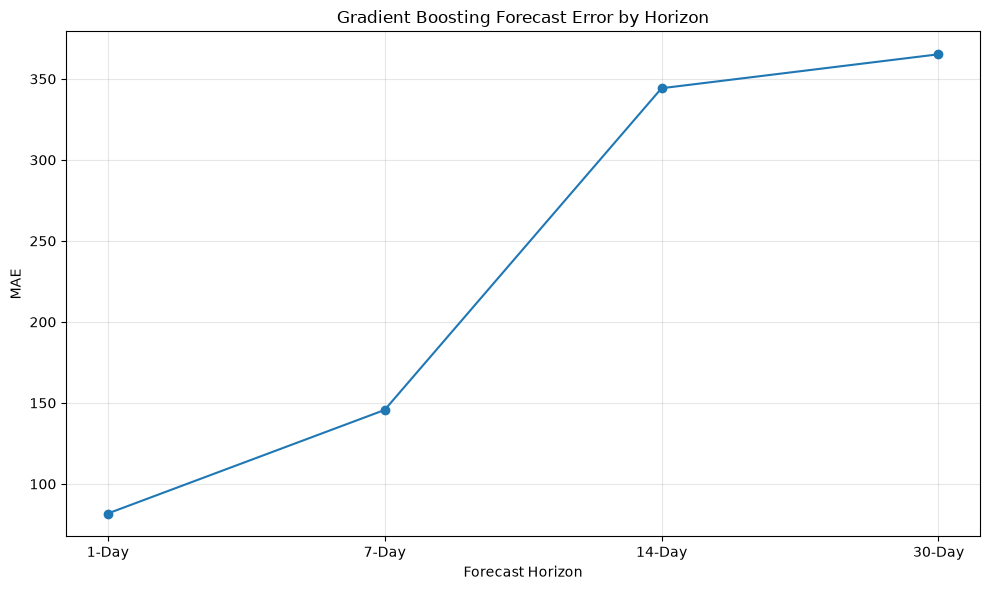

In [111]:
plt.figure(figsize=(10, 6))

plt.plot(
    horizon_results_df["Horizon"],
    horizon_results_df["MAE"],
    marker="o"
)

plt.title("Gradient Boosting Forecast Error by Horizon")
plt.xlabel("Forecast Horizon")
plt.ylabel("MAE")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

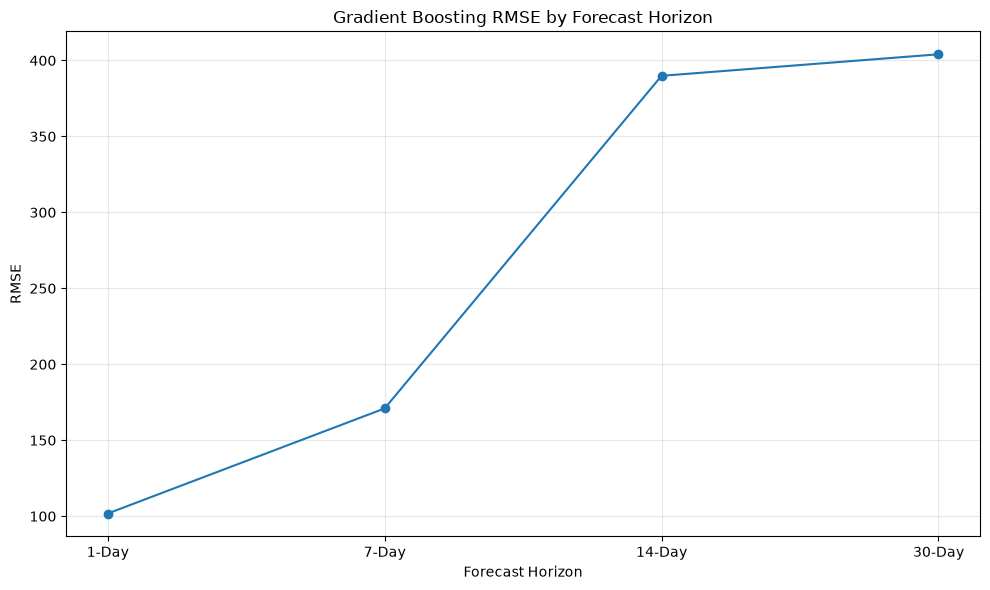

In [112]:
plt.figure(figsize=(10, 6))

plt.plot(
    horizon_results_df["Horizon"],
    horizon_results_df["RMSE"],
    marker="o"
)

plt.title("Gradient Boosting RMSE by Forecast Horizon")
plt.xlabel("Forecast Horizon")
plt.ylabel("RMSE")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

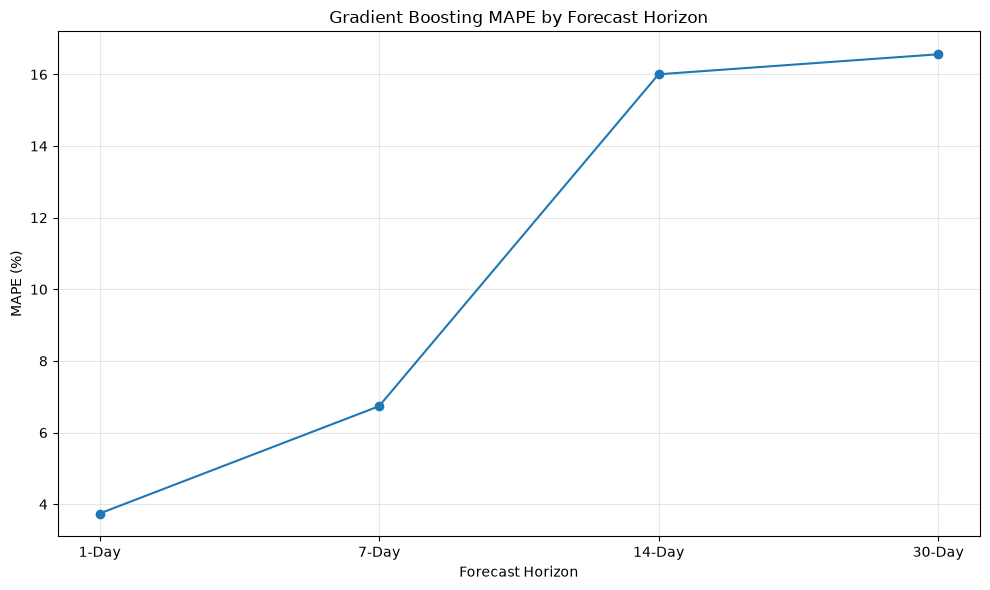

In [113]:
plt.figure(figsize=(10, 6))

plt.plot(
    horizon_results_df["Horizon"],
    horizon_results_df["MAPE"],
    marker="o"
)

plt.title("Gradient Boosting MAPE by Forecast Horizon")
plt.xlabel("Forecast Horizon")
plt.ylabel("MAPE (%)")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [114]:
horizon_results_df = horizon_results_df.round({
    "MAE": 2,
    "RMSE": 2,
    "MAPE": 2
})

horizon_results_df

,Horizon,Model,Train Size,Test Size,MAE,RMSE,MAPE
0,1-Day,Gradient Boosting,392,99,81.73,101.76,3.74
1,7-Day,Gradient Boosting,389,98,145.66,170.93,6.74
2,14-Day,Gradient Boosting,388,97,344.23,389.87,16.00
3,30-Day,Gradient Boosting,384,97,365.18,404.04,16.56


In [115]:
horizon_results_df["Forecast Accuracy (%)"] = (
    100 - horizon_results_df["MAPE"]
).round(2)

horizon_results_df

,Horizon,Model,Train Size,Test Size,MAE,RMSE,MAPE,Forecast Accuracy (%)
0,1-Day,Gradient Boosting,392,99,81.73,101.76,3.74,96.26
1,7-Day,Gradient Boosting,389,98,145.66,170.93,6.74,93.26
2,14-Day,Gradient Boosting,388,97,344.23,389.87,16.00,84.00
3,30-Day,Gradient Boosting,384,97,365.18,404.04,16.56,83.44


In [116]:
horizon_results[0]


{'Model': 'Gradient Boosting',
 'Target': 'target_1d',
 'Train Size': 392,
 'Test Size': 99,
 'MAE': 81.73031341599793,
 'RMSE': np.float64(101.75847879424165),
 'MAPE': np.float64(3.7396173472899745),
 'Predictions': array([2288.75534049, 2290.91655094, 2286.02685153, 2272.86635919,
        2281.10351002, 2283.26472046, 2278.37502106, 2278.78357036,
        2285.50010794, 2287.66131838, 2282.77161898, 2278.78357036,
        2315.07952402, 2325.3692377 , 2332.61251888, 2328.62447026,
        2339.46166484, 2333.95300297, 2348.74796216, 2360.58806296,
        2302.5935451 , 2289.68837826, 2296.24618663, 2219.48125387,
        2157.47112394, 2155.88533034, 2157.28049725, 2165.50556139,
        2165.50556139, 2163.8054066 , 2169.28226124, 2169.10494807,
        2164.15251191, 2160.49268939, 2162.65627022, 2162.24796209,
        2159.26011431, 2155.27625759, 2161.97397849, 2163.3391656 ,
        2159.35975513, 2159.03648791, 2167.70714472, 2168.70107416,
        2165.30491825, 2159.3134227

In [117]:
one_day_result = next(
    r for r in horizon_results
    if r["Horizon"] == "1-Day"
)

print(one_day_result["MAE"])
print(one_day_result["RMSE"])
print(one_day_result["MAPE"])

81.73031341599793
101.75847879424165
3.7396173472899745


In [118]:
one_day_result = next(
    r for r in horizon_results
    if r["Horizon"] == "1-Day"
)

one_day_data = model_df[
    forecast_features + ["target_1d"]
].dropna(
    subset=forecast_features + ["target_1d"]
).reset_index(drop=True)

split_index = int(len(one_day_data) * 0.80)

one_day_test = one_day_data.iloc[split_index:].copy()

one_day_test["Predicted"] = one_day_result["Predictions"]

one_day_test["Actual"] = one_day_test["target_1d"]

one_day_test = one_day_test.reset_index(drop=True)

print(one_day_test.shape)
one_day_test.head()

(99, 24)


,hhs_lag_1,hhs_lag_7,hhs_lag_14,hhs_lag_28,transfer_lag_1,transfer_lag_7,transfer_lag_14,discharge_lag_1,discharge_lag_7,discharge_lag_14,...,day_of_week,day_of_month,month,quarter,year,week_of_year,is_weekend,target_1d,Predicted,Actual
0,2301.0,2308.0,2282.0,2193.0,12.0,5.0,9.0,4.0,6.0,13.0,...,0,28,4,2,2025,18,0,2304.0,2288.755340,2304.0
1,2307.0,2305.0,2286.0,2191.0,12.0,14.0,12.0,8.0,17.0,7.0,...,1,29,4,2,2025,18,0,2309.0,2290.916551,2309.0
2,2304.0,2300.0,2291.0,2208.0,11.0,4.0,5.0,15.0,11.0,8.0,...,2,30,4,2,2025,18,0,2306.0,2286.026852,2306.0
3,2309.0,2294.0,2288.0,2223.0,9.0,7.0,10.0,12.0,13.0,14.0,...,3,1,5,2,2025,18,0,2335.0,2272.866359,2335.0
4,2335.0,2307.0,2308.0,2237.0,10.0,12.0,5.0,5.0,8.0,6.0,...,0,5,5,2,2025,19,0,2339.0,2281.103510,2339.0


In [119]:
print(model_df.columns.tolist())

['Unnamed: 0', 'Date', 'Children apprehended and placed in CBP custody*', 'Children in CBP custody', 'Children transferred out of CBP custody', 'Children in HHS Care', 'Children discharged from HHS Care', 'day_of_week', 'day_of_month', 'month', 'quarter', 'year', 'week_of_year', 'is_weekend', 'Net_Pressure', 'Discharge_to_Transfer_Ratio', 'hhs_lag_1', 'hhs_lag_7', 'hhs_lag_14', 'hhs_lag_28', 'transfer_lag_1', 'transfer_lag_7', 'transfer_lag_14', 'discharge_lag_1', 'discharge_lag_7', 'discharge_lag_14', 'hhs_rolling_mean_7d', 'hhs_rolling_mean_14d', 'hhs_rolling_std_7d', 'hhs_rolling_std_14d', 'target_1d', 'target_7d', 'target_14d', 'target_30d', 'exact_target_1d', 'exact_target_7d', 'exact_target_14d', 'exact_target_30d']


In [120]:
one_day_date_data = model_df[
    ["Date"] + forecast_features + ["target_1d"]
].dropna(
    subset=forecast_features + ["target_1d"]
).reset_index(drop=True)

one_day_test = one_day_date_data.iloc[split_index:].copy()

one_day_test["Predicted"] = one_day_result["Predictions"]
one_day_test["Actual"] = one_day_test["target_1d"]

one_day_test = one_day_test.reset_index(drop=True)

one_day_test[
    ["Date", "Actual", "Predicted"]
].head(10)

,Date,Actual,Predicted
0,2025-04-28,2304.0,2288.755340
1,2025-04-29,2309.0,2290.916551
2,2025-04-30,2306.0,2286.026852
3,2025-05-01,2335.0,2272.866359
4,2025-05-05,2339.0,2281.103510
5,2025-05-06,2335.0,2283.264720
6,2025-05-07,2361.0,2278.375021
7,2025-05-08,2385.0,2278.783570
8,2025-05-12,2394.0,2285.500108
9,2025-05-13,2394.0,2287.661318


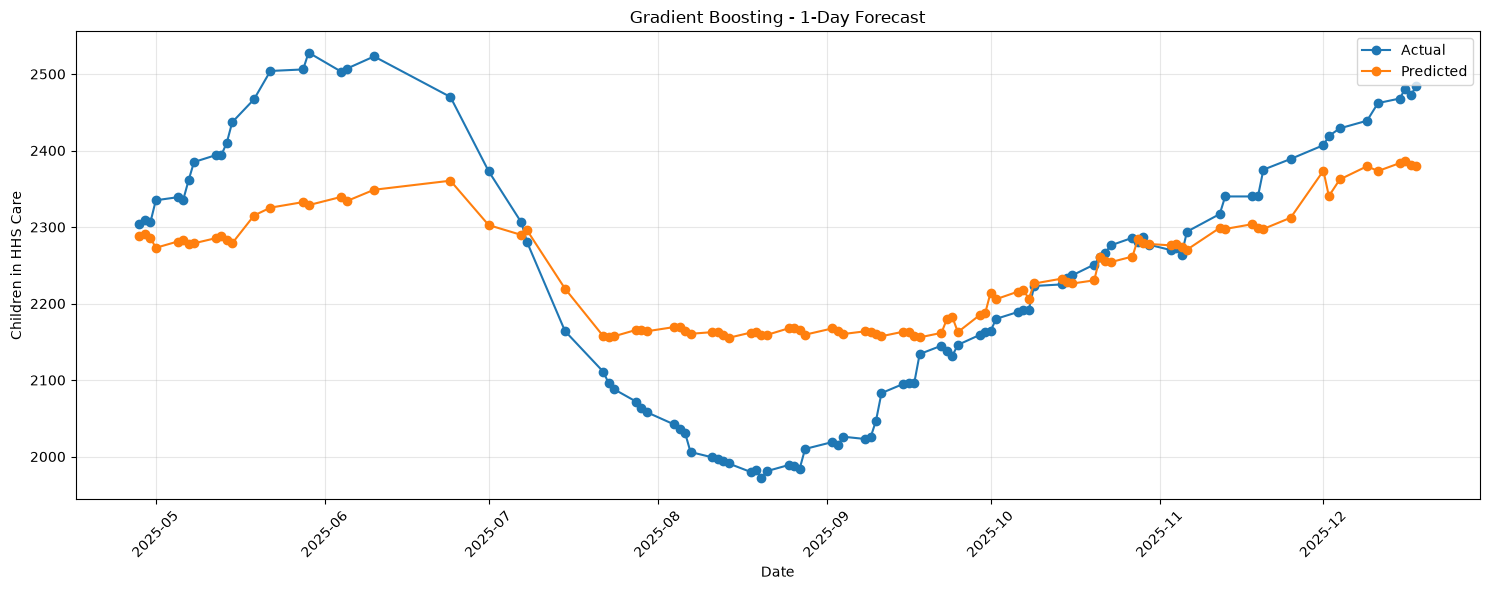

In [121]:
plt.figure(figsize=(15, 6))

plt.plot(
    one_day_test["Date"],
    one_day_result["Actual"],
    label="Actual",
    marker="o"
)

plt.plot(
    one_day_test["Date"],
    one_day_result["Predictions"],
    label="Predicted",
    marker="o"
)

plt.title(
    "Gradient Boosting - 1-Day Forecast"
)

plt.xlabel("Date")
plt.ylabel("Children in HHS Care")

plt.legend()
plt.grid(alpha=0.3)

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [122]:
all_horizon_predictions = []

for result in horizon_results:

    test_data = result["Test_Data"].copy()

    temp = pd.DataFrame({
        "Date": test_data["Date"].values,
        "Horizon": result["Horizon"],
        "Actual": result["Actual"].values,
        "Predicted": result["Predictions"]
    })

    temp["Error"] = (
        temp["Actual"] - temp["Predicted"]
    )

    temp["Absolute_Error"] = (
        temp["Error"].abs()
    )

    all_horizon_predictions.append(temp)

all_horizon_predictions_df = pd.concat(
    all_horizon_predictions,
    ignore_index=True
)

all_horizon_predictions_df.head()

,Date,Horizon,Actual,Predicted,Error,Absolute_Error
0,2025-04-28,1-Day,2304.0,2288.755340,15.244660,15.244660
1,2025-04-29,1-Day,2309.0,2290.916551,18.083449,18.083449
2,2025-04-30,1-Day,2306.0,2286.026852,19.973148,19.973148
3,2025-05-01,1-Day,2335.0,2272.866359,62.133641,62.133641
4,2025-05-05,1-Day,2339.0,2281.103510,57.896490,57.896490


In [107]:
print(model_df.columns.tolist())
print("Index name:", model_df.index.name)

['Unnamed: 0', 'Date', 'Children apprehended and placed in CBP custody*', 'Children in CBP custody', 'Children transferred out of CBP custody', 'Children in HHS Care', 'Children discharged from HHS Care', 'day_of_week', 'day_of_month', 'month', 'quarter', 'year', 'week_of_year', 'is_weekend', 'Net_Pressure', 'Discharge_to_Transfer_Ratio', 'hhs_lag_1', 'hhs_lag_7', 'hhs_lag_14', 'hhs_lag_28', 'transfer_lag_1', 'transfer_lag_7', 'transfer_lag_14', 'discharge_lag_1', 'discharge_lag_7', 'discharge_lag_14', 'hhs_rolling_mean_7d', 'hhs_rolling_mean_14d', 'hhs_rolling_std_7d', 'hhs_rolling_std_14d', 'target_1d', 'target_7d', 'target_14d', 'target_30d', 'exact_target_1d', 'exact_target_7d', 'exact_target_14d', 'exact_target_30d']
Index name: None


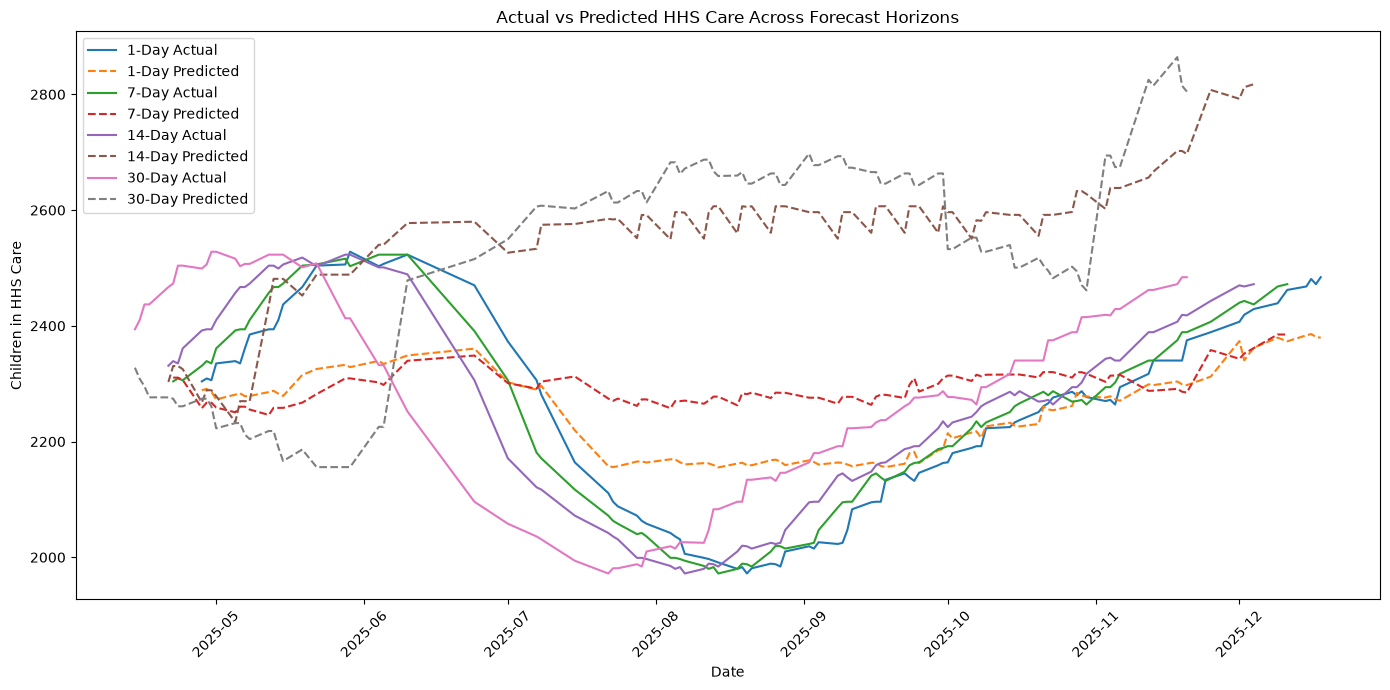

In [125]:
plt.figure(figsize=(14, 7))

for horizon in ["1-Day", "7-Day", "14-Day", "30-Day"]:

    horizon_data = all_horizon_predictions_df[
        all_horizon_predictions_df["Horizon"] == horizon
    ].copy()

    plt.plot(
        horizon_data["Date"],
        horizon_data["Actual"],
        label=f"{horizon} Actual"
    )

    plt.plot(
        horizon_data["Date"],
        horizon_data["Predicted"],
        linestyle="--",
        label=f"{horizon} Predicted"
    )

plt.xlabel("Date")
plt.ylabel("Children in HHS Care")
plt.title("Actual vs Predicted HHS Care Across Forecast Horizons")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [127]:
error_summary= (
    all_horizon_predictions_df.groupby("Horizon").agg(
        Mean_Error= ("Error","mean"),
        MAE= ("Absolute_Error", "mean"),
        Max_Error= ("Absolute_Error", "max"),
        Median_Error= ("Absolute_Error", "median")
    )
    .reset_index()
)

error_summary

,Horizon,Mean_Error,MAE,Max_Error,Median_Error
0,1-Day,-12.145464,81.730313,199.375530,69.280497
1,14-Day,-310.245428,344.234764,623.461075,337.781883
2,30-Day,-236.900796,365.182129,667.566227,352.165303
3,7-Day,-61.170885,145.658985,305.644271,133.190251


In [128]:
largest_errors= (
    all_horizon_predictions_df.sort_values(
        "Absolute_Error",
        ascending=False
    ).head(20)
)

largest_errors[
    [
        "Date",
        "Horizon",
        "Actual",
        "Predicted",
        "Error",
        "Absolute_Error"
    ]
]

,Date,Horizon,Actual,Predicted,Error,Absolute_Error
333,2025-08-05,30-Day,2015.0,2682.566227,-667.566227,667.566227
332,2025-08-04,30-Day,2019.0,2682.566227,-663.566227,663.566227
336,2025-08-11,30-Day,2025.0,2687.174383,-662.174383,662.174383
326,2025-07-22,30-Day,1972.0,2632.982211,-660.982211,660.982211
330,2025-07-29,30-Day,1984.0,2632.982211,-648.982211,648.982211
335,2025-08-07,30-Day,2026.0,2671.717051,-645.717051,645.717051
329,2025-07-28,30-Day,1988.0,2632.982211,-644.982211,644.982211
337,2025-08-12,30-Day,2047.0,2687.174383,-640.174383,640.174383
334,2025-08-06,30-Day,2026.0,2662.675091,-636.675091,636.675091
327,2025-07-23,30-Day,1981.0,2613.091075,-632.091075,632.091075


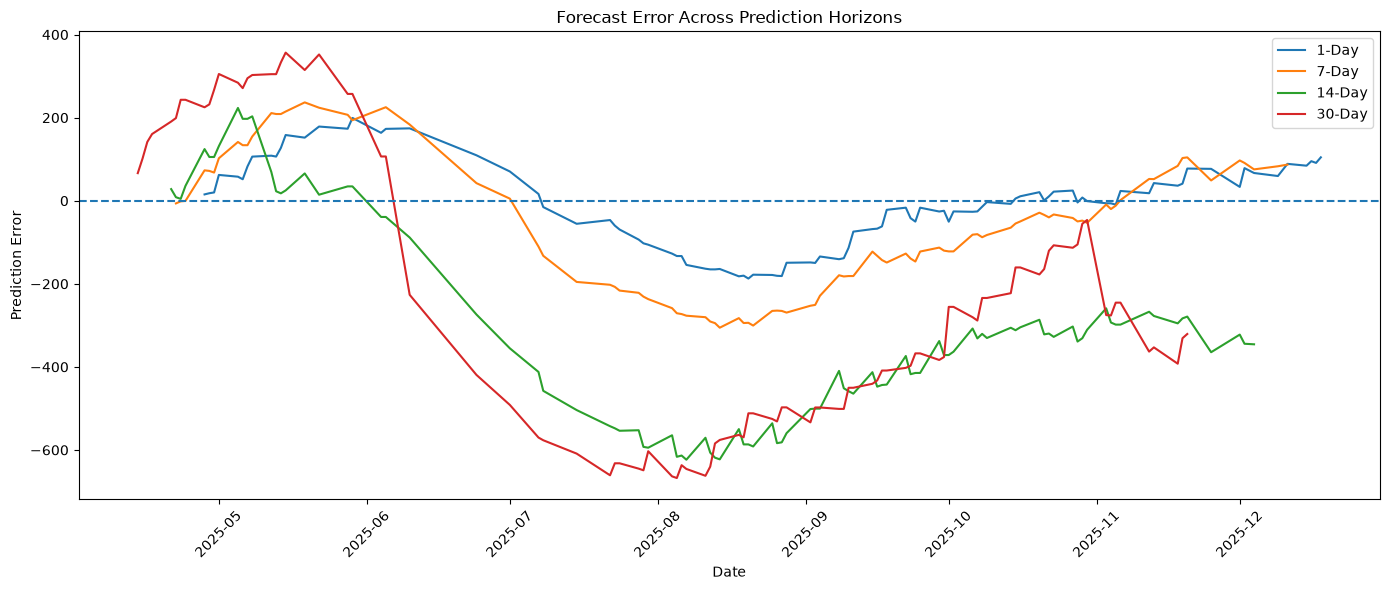

In [131]:
plt.figure(figsize=(14,6))

for horizon in ["1-Day", "7-Day", "14-Day", "30-Day"]:
    horizon_data= all_horizon_predictions_df[
        all_horizon_predictions_df["Horizon"] == horizon
    ].copy()
    
    plt.plot(
        horizon_data["Date"],
        horizon_data["Error"],
        label= horizon
    )
    
plt.axhline(y=0, linestyle= "--")
plt.xlabel("Date")
plt.ylabel("Prediction Error")
plt.title("Forecast Error Across Prediction Horizons")
plt.legend()
plt.xticks(rotation= 45)
plt.tight_layout()
plt.show()

In [132]:
all_horizon_predictions_df["Percentage_Error"] = (
    all_horizon_predictions_df["Error"]
    / all_horizon_predictions_df["Actual"]
) * 100

In [133]:
percentage_error_summary= (
    all_horizon_predictions_df.groupby("Horizon").agg(
        Mean_Percentage_Error= ("Percentage_Error", "mean"),
        Mean_Absolute_Percentage_Error= (
            "Percentage_Error",
            lambda x: x.abs().mean()
        ),
        Max_Absolute_Percentage_Error= (
            "Percentage_Error",
            lambda x: x.abs().max()
        )
    ).reset_index()
)

percentage_error_summary

,Horizon,Mean_Percentage_Error,Mean_Absolute_Percentage_Error,Max_Absolute_Percentage_Error
0,1-Day,-0.883241,3.739617,9.501002
1,14-Day,-14.614794,16.003222,31.615673
2,30-Day,-11.406338,16.561257,33.518368
3,7-Day,-3.289761,6.736692,15.499202


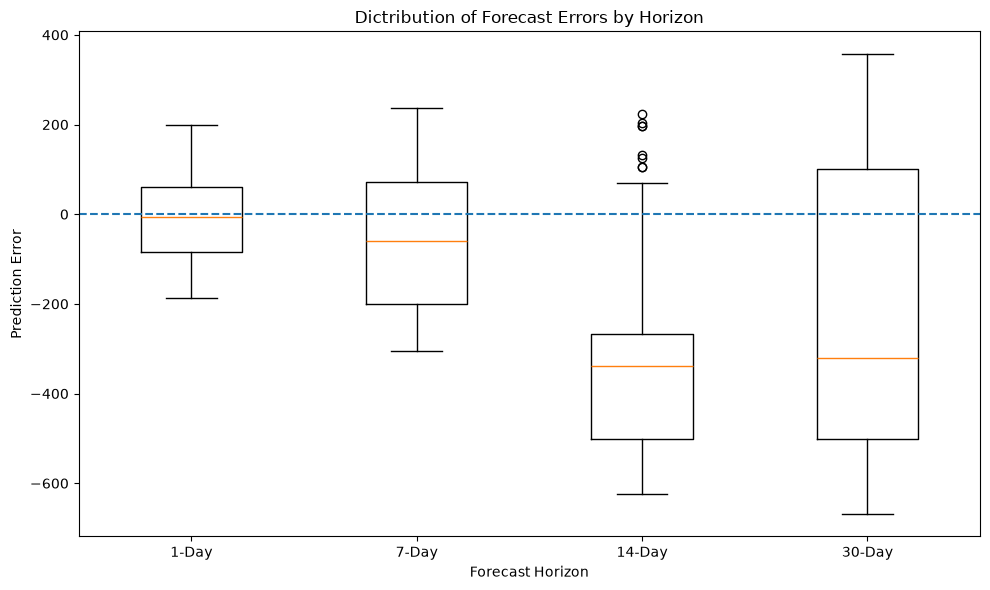

In [141]:
plt.figure(figsize=(10,6))

plt.boxplot(
    [
        all_horizon_predictions_df[
            all_horizon_predictions_df["Horizon"] == horizon
        ]["Error"]
        for horizon in ["1-Day", "7-Day", "14-Day", "30-Day"]
    ],
    tick_labels=["1-Day", "7-Day", "14-Day", "30-Day"]
)

plt.axhline(y=0, linestyle="--")
plt.xlabel("Forecast Horizon")
plt.ylabel("Prediction Error")
plt.title("Dictribution of Forecast Errors by Horizon")
plt.tight_layout()
plt.show()

In [138]:
bias_summary= (
    all_horizon_predictions_df.groupby("Horizon").agg(
        Mean_Error= ("Error", "mean"),
        Mean_Actual= ("Actual", "mean"),
        Mean_Predicted= ("Predicted", "mean")
    ).reset_index()
)

bias_summary["Bias_Percenatge"] = (
    bias_summary["Mean_Error"]
    / bias_summary["Mean_Actual"]
) * 100

bias_summary

,Horizon,Mean_Error,Mean_Actual,Mean_Predicted,Bias_Percenatge
0,1-Day,-12.145464,2229.646465,2241.791929,-0.544726
1,14-Day,-310.245428,2246.175258,2556.420685,-13.812165
2,30-Day,-236.900796,2286.020619,2522.921415,-10.363021
3,7-Day,-61.170885,2232.214286,2293.385170,-2.740368


In [145]:
direction_summary= (
    all_horizon_predictions_df.groupby("Horizon").agg(
        Over_Predictions= (
            "Error",
            lambda x: (x < 0).sum()
        ),
        Under_Predictions= (
            "Error",
            lambda x: (x > 0).sum()
        ),
        Total_Predictions= ("Error", "count")
    ).reset_index()
)

direction_summary["Over_Prediction_Percentage"]= (
    direction_summary["Over_Predictions"]
    / direction_summary["Total_Predictions"]
) * 100

direction_summary["Under_Prediction_Percenatge"]= (
    direction_summary["Under_Predictions"]
    / direction_summary["Total_Predictions"]
) * 100

direction_summary

,Horizon,Over_Predictions,Under_Predictions,Total_Predictions,Over_Prediction_Percentage,Under_Prediction_Percenatge
0,1-Day,53,46,99,53.535354,46.464646
1,14-Day,77,20,97,79.381443,20.618557
2,30-Day,71,26,97,73.195876,26.804124
3,7-Day,65,33,98,66.326531,33.673469
